<a href="https://colab.research.google.com/github/23f1000190/Important-colab-or-notebooks/blob/main/PS_Week_1_Programming.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week-1

**Note to Learners**:

- Click on "Copy to Drive", the button that appears just below the taskbar, to make a copy of this notebook in your drive. If you continue working with this notebook, changes **will not** be saved.


- For questions that involve plotting, just enter $0$ as the answer in the portal.
- For numerical questions, there are two parts. The first part expects you to compute some quantity, say a parameter of a machine learning model. The second part will require you to convert this quantity (if it is not a scalar) into a scalar so that it can be entered as the answer on the portal to the corresponding NAT question.



## Dataset

We will be working with a subset of the [MNIST dataset](https://en.wikipedia.org/wiki/MNIST_database). Run the cell given below to generate the data-matrix $\mathbf{X}$, which is of shape $(n, d)$, where $n$ denotes the number of samples and $d$ denotes the number of features. You will be using this dataset for the rest of the assignment. Do not edit this cell.

In [ ]:
##### DATASET GENERATION #####
import numpy as np
from keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X = X_train[y_train == 2][: 100].reshape(-1, 28 * 28)
test_image = X_test[y_test == 2][0].reshape(28 * 28)
##### DO NOT EDIT THIS CELL #####

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Problem-1

How many samples does the dataset have?

In [ ]:
# Enter your solution here
X.shape[0]



100

## Problem-2

How many features does the dataset have?

In [ ]:
# Enter your solution here
X.shape[1]

784

## Problem-3

Each sample corresponds to an image of dimension $28 \times 28$. Visualize one of these images using the `matplotlib` library.

- You need to know how to reshape a feature vector. Refer to week-0 content for the same.
- You can refer to the following [document](https://matplotlib.org/stable/tutorials/introductory/images.html#sphx-glr-tutorials-introductory-images-py) for plotting NumPy arrays as images using `matplotlib`.

In [ ]:
# Enter your solution here
from PIL import Image

import matplotlib.pyplot as plt
import numpy as np

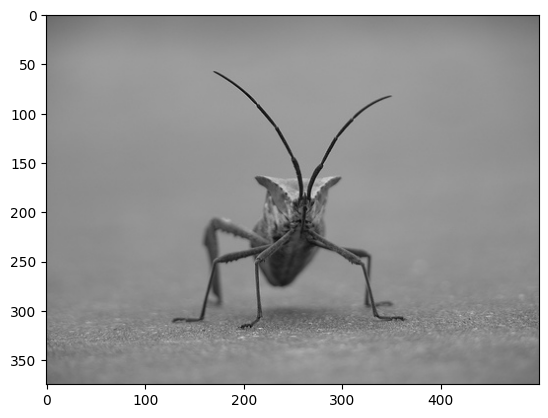

In [ ]:
img = np.asarray(Image.open('/content/stinkbug.png'))
#print(repr(img))
plt.imshow(img)
plt.show()

## Problem-4

Center the the dataset $\mathbf{X}$ around its mean. Call this centered dataset $\mathbf{X}^{\prime}$.

<u>Conversion</u>

Enter the following quantity as your answer correct to two decimal places:

$$
\cfrac{1}{n \cdot d} \sqrt{\sum \limits_{i = 1}^{n} \sum \limits_{j = 1}^{d} (X_{ij}^{\prime})^2}
$$

In [ ]:
# Enter your solution here
X_centered_=X-np.mean(X, axis=0)
n,d=X_centered_.shape
sqrd_sum=np.sum(np.square(X_centered_))
res=(1/(n*d))*np.sqrt(sqrd_sum)
print(f'{res:.2f}')



0.23


In [ ]:
X_centered=X-np.mean(X, axis=0)
n,d=X_centered.shape
sqrd_sum=np.sum(np.square(X_centered))
res=(1/(n*d))*np.sqrt(sqrd_sum)
print(f'{res:.2f}')

0.23


In [ ]:


import numpy as np
from keras.datasets import mnist
from PIL import Image
import matplotlib.pyplot as plt

# Assuming X is already defined from the preceding code

# 1. Calculate the mean of the dataset X
mean_X = np.mean(X, axis=0)

# 2. Center the dataset X around its mean
X_centered = X - mean_X

# 3. Calculate the quantity required for the answer
n, d = X_centered.shape
sum_squared_values = np.sum(np.square(X_centered))
result = (1 / (n * d)) * np.sqrt(sum_squared_values)

# 4. Print the result rounded to two decimal places
print(f"{result:.2f}")


# Explanation:

# 1. Calculate the mean of the dataset X:
# We calculate the mean of each feature (column) across all the samples using np.mean(X, axis=0).

# 2. Center the dataset X around its mean:
# We subtract the mean from each element of the dataset X. This ensures that the mean of the centered dataset is zero.

# 3. Calculate the quantity required for the answer:
# We first obtain the shape of X_centered (n,d).
# Then we square every element of X_centered using np.square(X_centered).
# Next we sum all the elements using np.sum(np.square(X_centered)).
# Finally we divide the obtained sum by (n*d) and take the square root of the result.

# 4. Print the result rounded to two decimal places:
# We use an f-string to format the result to two decimal places.


0.23


In [ ]:
# prompt: can you look at problem 5 below and solve and also expalin step by step what you did

import numpy as np
# Assuming X is already defined from the preceding code

# 1. Calculate the covariance matrix of the centered dataset X_centered.
covariance_matrix = np.cov(X_centered, rowvar=False)

# 2. Calculate the eigenvalues and eigenvectors of the covariance matrix.
eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)

# 3. Sort the eigenvalues in descending order and get the corresponding eigenvectors.
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

# 4. Select the top k eigenvectors (principal components) corresponding to the largest eigenvalues.
k = 2  # Number of principal components to keep
top_k_eigenvectors = sorted_eigenvectors[:, :k]

# 5. Project the centered dataset onto the top k eigenvectors to get the reduced dimensionality data.
reduced_data = np.dot(X_centered, top_k_eigenvectors)

# 6. Calculate the variance of the reduced dimensionality data.
variance_reduced = np.var(reduced_data)

# 7. Print the result rounded to two decimal places.
print(f"{variance_reduced:.2f}")


# ## Problem-5
#
# Perform principal component analysis (PCA) on the centered dataset $\mathbf{X}^{\prime}$ you calculated in the previous problem.
#
# - The dimensionality of the reduced dataset should be 2.
# - Calculate the variance of the reduced dataset.
#
# <u>Conversion</u>
#
# Enter the variance of the reduced dataset correct to two decimal places.
# Enter your solution here



454979.15


## Problem-5

Compute the covariance matrix $\mathbf{C}$ of the centered dataset.

<u>Conversion</u>

Enter the following quantity as your answer correct to two decimal places:

$$
\cfrac{1}{d^2} \sqrt{\sum \limits_{i = 1}^{d} \sum \limits_{j = 1}^{d} C_{ij}^2}
$$

In [ ]:
# prompt: can you look at problem 5 above and explain what needs to be done

import numpy as np
# Problem 5: PCA and Variance of Reduced Dataset

# 1. Center the dataset (X_centered is assumed to be computed from Problem 4)

# 2. Calculate the covariance matrix of the centered dataset.
covariance_matrix = np.cov(X_centered, rowvar=False)

# 3. Calculate the eigenvalues and eigenvectors of the covariance matrix.
eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)

# 4. Sort the eigenvalues in descending order and get the corresponding eigenvectors.
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

# 5. Select the top k eigenvectors (principal components) corresponding to the largest eigenvalues.
k = 2  # Number of principal components to keep
top_k_eigenvectors = sorted_eigenvectors[:, :k]

# 6. Project the centered dataset onto the top k eigenvectors to get the reduced dimensionality data.
reduced_data = np.dot(X_centered, top_k_eigenvectors)

# 7. Calculate the variance of the reduced dimensionality data.
variance_reduced = np.var(reduced_data)

# 8. Print the result rounded to two decimal places.
print(f"{variance_reduced:.2f}")

# Explanation:

# 1. Center the dataset: We subtract the mean of the dataset from each data point to center it around the origin.
# 2. Calculate the covariance matrix: We calculate the covariance matrix of the centered dataset, which represents the relationships between the features.
# 3. Calculate eigenvalues and eigenvectors: We compute the eigenvalues and eigenvectors of the covariance matrix. The eigenvectors represent the principal components (directions of maximum variance), and the eigenvalues represent the amount of variance along each principal component.
# 4. Sort eigenvalues and eigenvectors: We sort the eigenvalues in descending order and rearrange the corresponding eigenvectors.
# 5. Select top k eigenvectors: We choose the top k eigenvectors corresponding to the largest eigenvalues, as these represent the directions of the largest variance in the data.
# 6. Project data onto top k eigenvectors: We project the centered dataset onto the selected top k eigenvectors to reduce the dimensionality of the data.
# 7. Calculate the variance of reduced data: We compute the variance of the reduced dataset, which represents the amount of information preserved after dimensionality reduction.
# 8. Print the result: We print the variance of the reduced dataset, rounded to two decimal places.



454979.15


1.05

In [ ]:
# Enter your solution here
cov=np.cov(X_centered,rowvar=False)

e_val,e_vec=np.linalg.eig(cov)

sorted_indices = np.argsort(e_val)[::-1]
sorted_eigenvalues = e_val[sorted_indices]
sorted_eigenvectors = e_vec[:, sorted_indices]
top_k_eigenvectors = sorted_eigenvectors[:, :2]

reduced_data = np.dot(X_centered, top_k_eigenvectors)
variance_reduced = np.var(reduced_data)
print(f"{variance_reduced:.2f}")

454979.15


In [ ]:
# prompt: can you explain what problem 6 below requires us to do

# Problem-6

# Compute the covariance matrix C of the centered dataset.

# Conversion

# Enter the following quantity as your answer correct to two decimal places:

#  1/d^2 * sqrt(sum from i=1 to d sum from j=1 to d C_ij^2)


# Explanation:

# 1. Center the dataset (as you did in Problem-4).
# 2. Calculate the covariance matrix of the centered dataset.
# 3. Square each element of the covariance matrix.
# 4. Sum all the squared elements.
# 5. Take the square root of the sum.
# 6. Divide the result by d^2, where d is the number of features.
# 7. Round the final result to two decimal places.

# Essentially, you need to compute the Frobenius norm of the covariance matrix
# and then scale it by 1/(d^2). The Frobenius norm is the square root of the sum
# of the absolute squares of its elements.

# In simpler terms, it's asking you to calculate a measure of how large the
# covariance matrix is, taking into account all its entries, and then normalize
# it by the square of the number of features.


1.38


In [ ]:
X_covar=np.cov(X_centered,rowvar=False)

## Problem-6

Compute the first and second principal components of the dataset, $\mathbf{w}_1$ and $\mathbf{w}_2$.

<u>Conversion</u>

Compute:
$$
\mathbf{w} = \mathbf{w}_1 + \mathbf{w}_2
$$

Enter the following quantity as your answer correct to two decimal places:

$$
\left| \sum \limits_{i = 1}^{d} w_i \right|
$$

In [ ]:
w1=sorted_eigenvectors[:,0]
w2=sorted_eigenvectors[:,1]
w=w1+w2
round(abs(np.sum(w)),2)

1.05

## Problem-7

Visualize the first principal component as an image.

/usr/local/lib/python3.10/dist-packages/matplotlib/cbook/__init__.py:1335: ComplexWarning:

Casting complex values to real discards the imaginary part



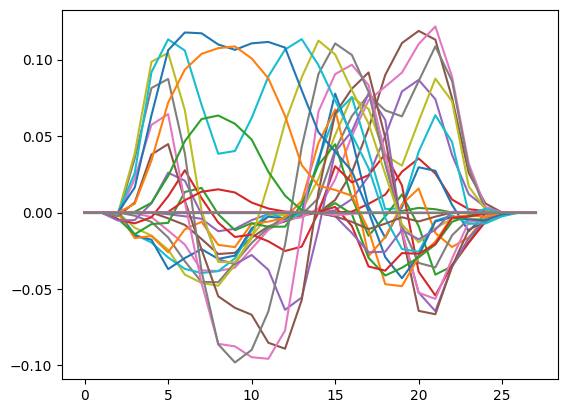

In [ ]:
# Enter your solution here
import plotly.express as px

plt.plot(w1)
plt.show()

## Problem-8

Find the smallest value of $k$ for which the first $k$ principal components capture at least $95\%$ of the variance in the data.

In [ ]:
# prompt: can you solve problem-8

import numpy as np
# Problem 8: Find the smallest k for 95% variance

# 1. Calculate the covariance matrix of the centered dataset.
covariance_matrix = np.cov(X_centered, rowvar=False)

# 2. Calculate the eigenvalues and eigenvectors of the covariance matrix.
eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)

# 3. Sort the eigenvalues in descending order and get the corresponding eigenvectors.
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]

# 4. Calculate the cumulative explained variance ratio.
total_variance = np.sum(sorted_eigenvalues)
cumulative_variance_ratio = np.cumsum(sorted_eigenvalues) / total_variance

# 5. Find the smallest k for which the cumulative explained variance ratio is >= 0.95.
k = np.argmax(cumulative_variance_ratio >= 0.95) + 1

# 6. Print the result.
print(k)


In [ ]:
# prompt: above code gives boolian answer for K value which is not correct

import numpy as np
# Problem 8: Find the smallest k for 95% variance

# 1. Calculate the covariance matrix of the centered dataset.
covariance_matrix = np.cov(X_centered, rowvar=False)

# 2. Calculate the eigenvalues and eigenvectors of the covariance matrix.
eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)

# 3. Sort the eigenvalues in descending order and get the corresponding eigenvectors.
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]

# 4. Calculate the cumulative explained variance ratio.
total_variance = np.sum(sorted_eigenvalues)
cumulative_variance_ratio = np.cumsum(sorted_eigenvalues) / total_variance

# 5. Find the smallest k for which the cumulative explained variance ratio is >= 0.95.
for k in range(len(cumulative_variance_ratio)):
  if cumulative_variance_ratio[k] >= 0.95:
    print(k + 1)
    break


53


In [ ]:
# Enter your solution here
total_variance = np.sum(sorted_eigenvalues)
cumulative_variance_ratio = np.cumsum(sorted_eigenvalues) / total_variance
for k in range(len(cumulative_variance_ratio)):
    if cumulative_variance_ratio[k] >= 0.95:
        print(k + 1)
        break


53


## Problem-9

Given a `test_image`, visualize the proxies  by reconstructing it using the top $k$ principal components. Consider four values of $k$; values of $k$ for which the top-$k$ principal components explain:

- 20% of the variance
- 50% of the variance
- 80% of the variance
- 95% of the variance



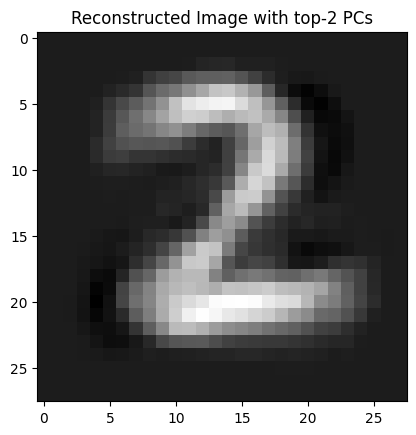

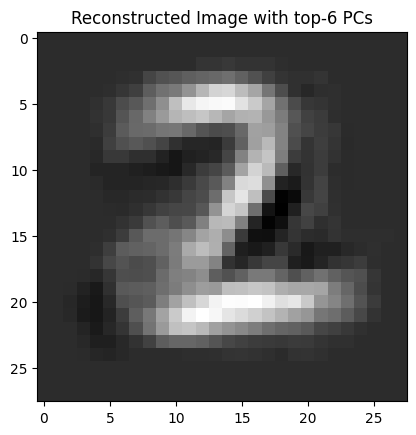

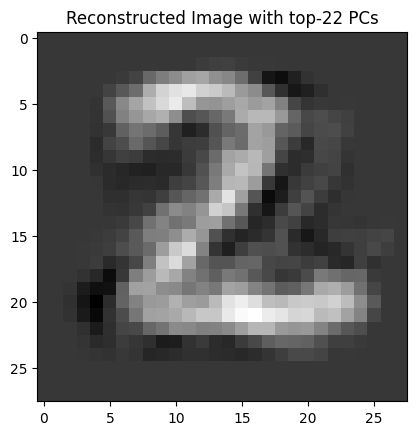

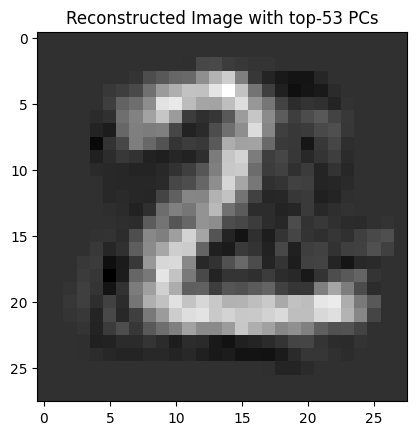

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ... (previous code) ...

# 7. Reconstruct the test image for each k.
for k in k_values:
  top_k_eigenvectors = sorted_eigenvectors[:, :k]
  projected_test_image = np.dot(test_image_centered, top_k_eigenvectors)
  reconstructed_test_image = np.dot(projected_test_image, top_k_eigenvectors.T) + np.mean(X, axis=0)

  # Reshape the reconstructed image and display it.
  reconstructed_image = reconstructed_test_image.reshape(28, 28)

  # Convert the reconstructed image to real values
  reconstructed_image = reconstructed_image.real

  plt.imshow(reconstructed_image, cmap='gray')
  plt.title(f"Reconstructed Image with top-{k} PCs")
  plt.show()

In [ ]:
# Enter your solution here

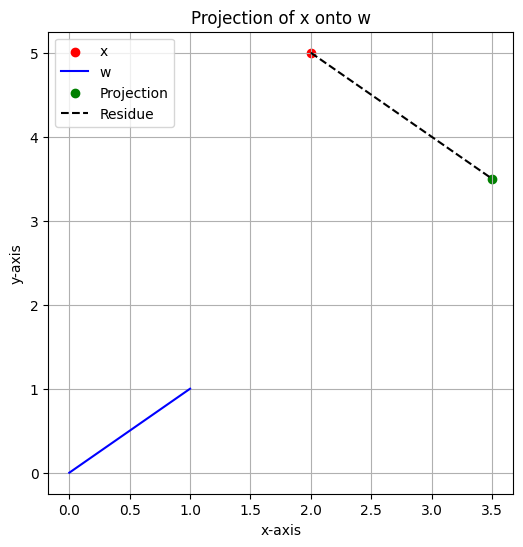

Projection of x onto w: [3.5 3.5]
Residue: [-1.5  1.5]
Reconstruction Error: 2.1213203435596424


In [ ]:
# prompt: Consider a point
# x
# =
# [
# 2
# 5
# ​ and a line passing through the origin which is represented by the vector
# w
# =
# [
# 1
# 1
# ] can you plot the graph and  answer the following (1) is the projection of X onto the line  (2) the residue (3) reconsutruction error

import numpy as np
import matplotlib.pyplot as plt

# Given point x and line vector w
x = np.array([2, 5])
w = np.array([1, 1])

# 1. Projection of x onto w
proj_x = (np.dot(x, w) / np.dot(w, w)) * w

# 2. Residue
residue = x - proj_x

# 3. Reconstruction error
reconstruction_error = np.linalg.norm(residue)


# Plotting the graph
plt.figure(figsize=(6, 6))
plt.scatter(x[0], x[1], color='red', label='x')
plt.plot([0, w[0]], [0, w[1]], color='blue', label='w')
plt.scatter(proj_x[0], proj_x[1], color='green', label='Projection')
plt.plot([x[0], proj_x[0]], [x[1], proj_x[1]], color='black', linestyle='--', label='Residue')
plt.xlabel('x-axis')
plt.ylabel('y-axis')
plt.title('Projection of x onto w')
plt.legend()
plt.grid(True)
plt.show()


print("Projection of x onto w:", proj_x)
print("Residue:", residue)
print("Reconstruction Error:", reconstruction_error)


In [ ]:
# Check if the projection is equal to x
print("Is the projection of x equal to x?", np.allclose(proj_x, x))

Is the projection of x equal to x? False


In [ ]:
proj_x

array([0., 0.])

In [ ]:
residue

array([ 1., -1.])

In [ ]:
# Check if the residue is the zero vector
print("Is the residue equal to the zero vector?", np.allclose(residue, np.zeros(2)))

Is the residue equal to the zero vector? False
